# Preliminary data analysis of HIVDRD

In [1]:
import pandas as pd
from holoviews.plotting.bokeh.styles import font_size

import data_preprocessing
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import data_preprocessing

files = [r"./data/INI_DataSet.txt",  r"./data/NNRTI_DataSet.txt", r"./data/NRTI_DataSet.txt", r"./data/PI_DataSet.txt"]

## Evaluating properties of the datasets

RAL
RAL
0.0    405
1.0    121
2.0    207
Name: count, dtype: int64
EVG
EVG
0.0    354
1.0    140
2.0    180
Name: count, dtype: int64
DTG
DTG
0.0    279
1.0     20
2.0     18
Name: count, dtype: int64
BIC
BIC
0.0    152
1.0     10
2.0      5
Name: count, dtype: int64
EFV
EFV
0.0    1199
1.0     231
2.0     782
Name: count, dtype: int64
NVP
NVP
0.0    1017
1.0     111
2.0    1082
Name: count, dtype: int64
ETR
ETR
0.0    731
1.0    133
2.0    120
Name: count, dtype: int64
RPV
RPV
0.0    117
1.0     29
2.0     42
Name: count, dtype: int64
3TC
3TC
0.0     864
1.0     209
2.0    1049
Name: count, dtype: int64
ABC
ABC
0.0    691
1.0    810
2.0    556
Name: count, dtype: int64
AZT
AZT
0.0    1140
1.0     392
2.0     611
Name: count, dtype: int64
D4T
D4T
0.0    1149
1.0     616
2.0     388
Name: count, dtype: int64
DDI
DDI
0.0    987
1.0    979
2.0    187
Name: count, dtype: int64
TDF
TDF
0.0    1239
1.0     377
2.0     198
Name: count, dtype: int64
FPV
FPV
0.0    1251
1.0     452
2.0     543


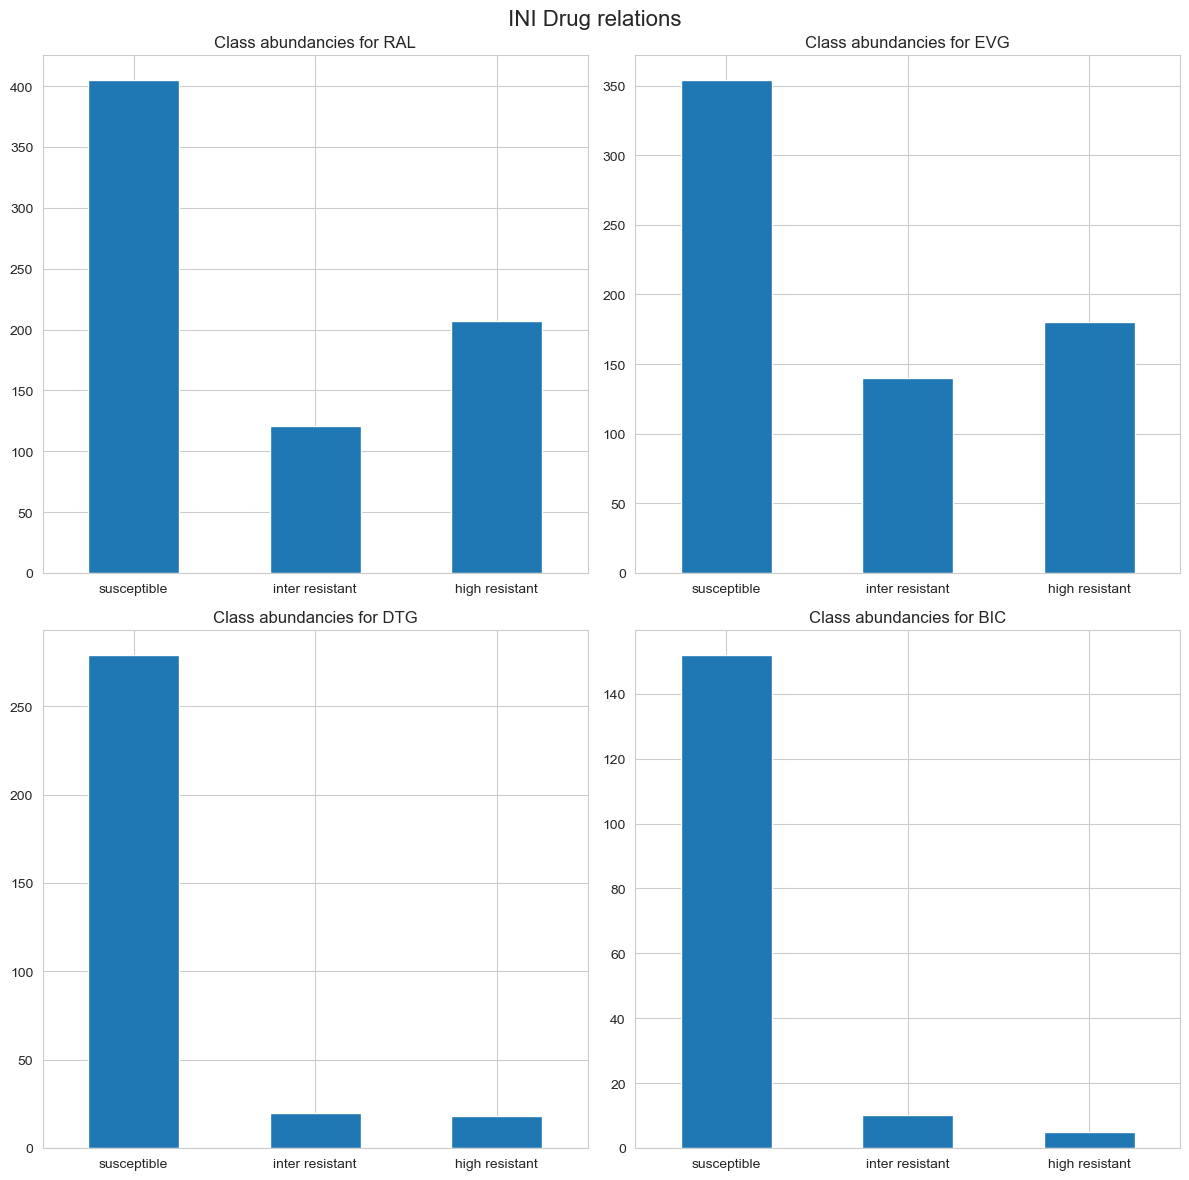

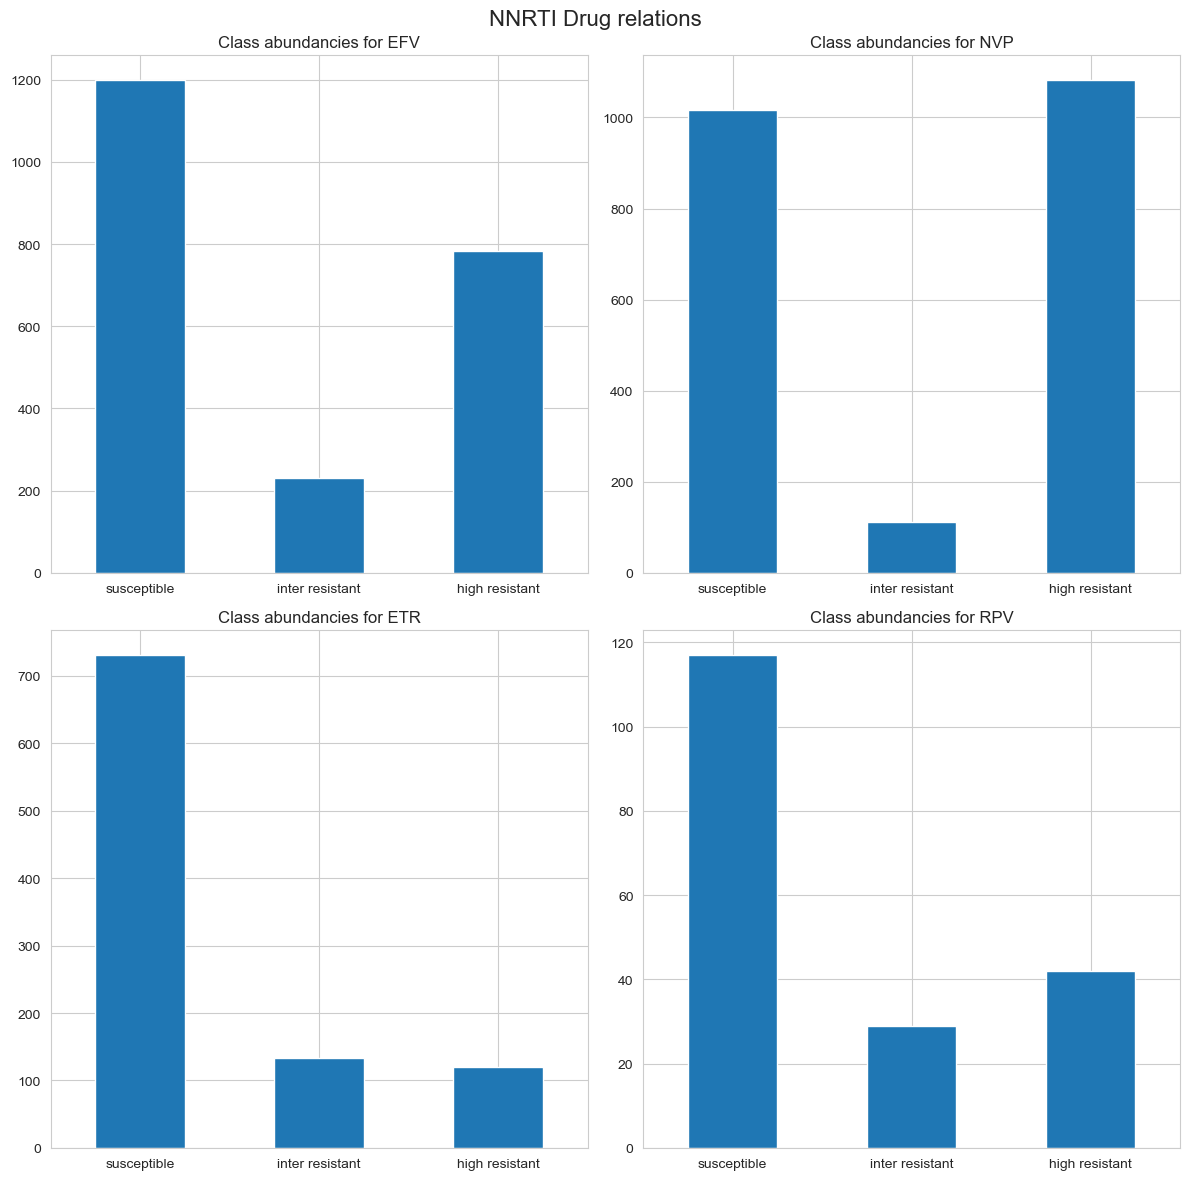

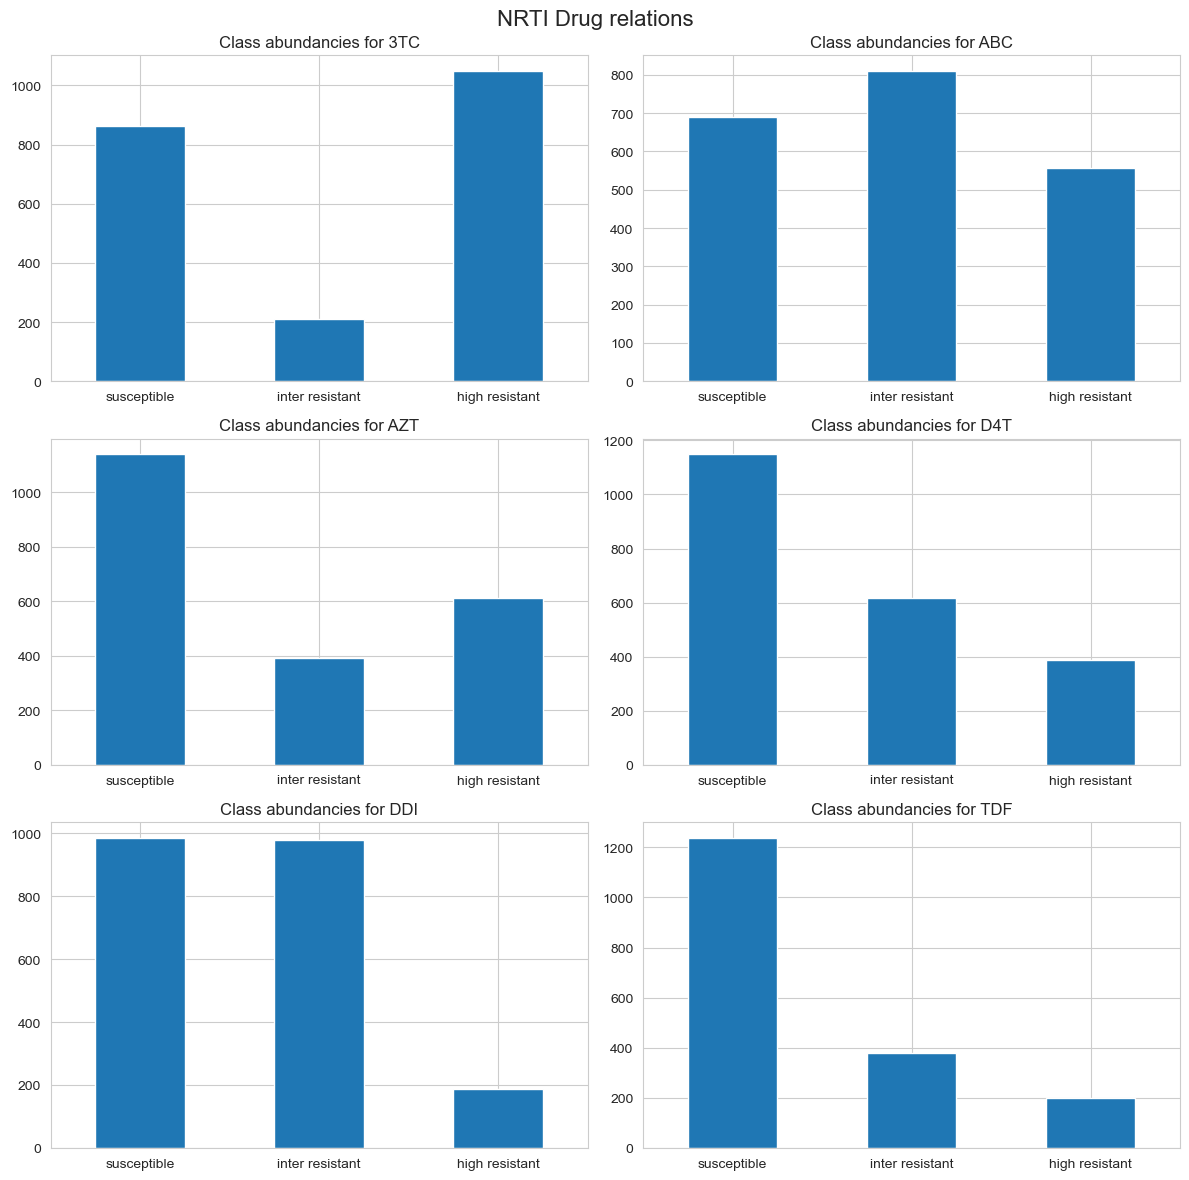

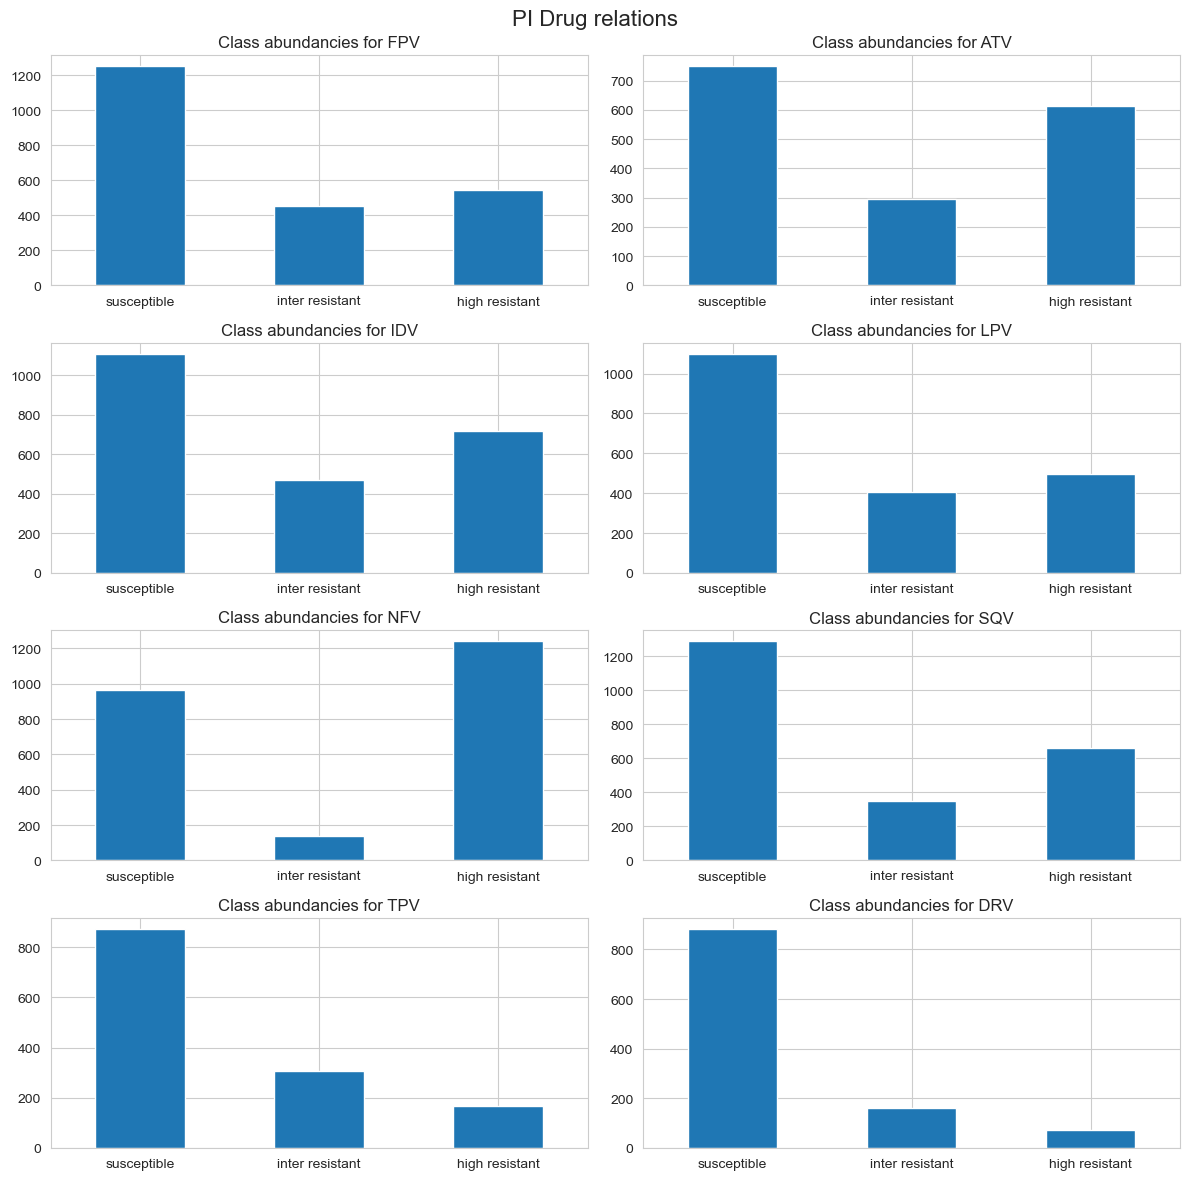

In [2]:
#checking the class imbalance per drug:

for file in files:

    _, Y, drugs = data_preprocessing.hq_hiv_loader(file, drop_na=False, class_mode="multiclass")


    fig, axs = plt.subplots(len(drugs) // 2 + len(drugs) % 2,2,figsize=(12,12), layout="tight")
    fig.subplots_adjust(hspace = 0.5)
    axs = axs.flatten()

    for i, drug in enumerate(drugs):

        class_counts = Y[drug].value_counts(sort=False).sort_index()
        print(drug)
        print(class_counts)


        class_counts.plot(kind="bar", ax=axs[i])
        axs[i].tick_params("x", rotation=0)
        #ax.set_ylabels("# of samples")
        axs[i].set_xticklabels(["susceptible", "inter resistant", "high resistant"])
        axs[i].set_xlabel('')
        axs[i].set_title('Class abundancies for ' + drug)

    fig.suptitle(file.split("/")[-1].strip("_DataSet.txt") + " Drug relations", fontsize=16)
    #plt.show()



[0.71701306 0.12394047 0.15904647]
[0.59186275 0.11101864 0.29711861]
[0.49169645 0.27064087 0.23766268]
[0.55704518 0.17057759 0.27237724]


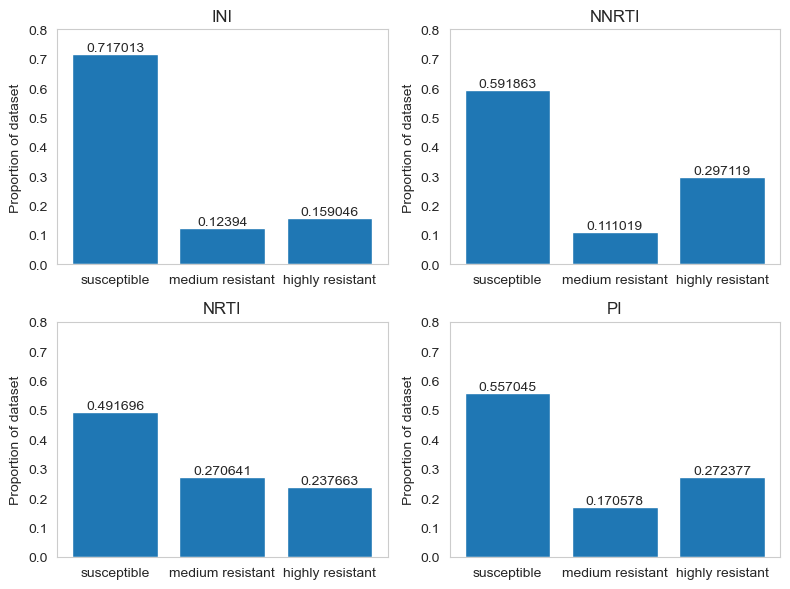

In [9]:
#checking the average class imbalance per dataset:

fig, axs = plt.subplots(2, 2, figsize=(8, 6), layout="tight")

axs = axs.flatten()

for i, file in enumerate(files):

    _, Y, drugs = data_preprocessing.hq_hiv_loader(file, drop_na=False, class_mode="multiclass")

    avg_label_imb = np.zeros(3)

    for drug in drugs:

        class_counts = np.array(Y[drug].value_counts(sort=False).sort_index())

        #print(np.array(class_counts) / sum(np.array(class_counts)))


        avg_label_imb += class_counts / sum(class_counts)

    avg_label_imb /= len(drugs)

    print(avg_label_imb)

    ax = axs[i]

    rect = ax.bar(["susceptible", "medium resistant", "highly resistant"], avg_label_imb)
    ax.bar_label(rect)
    ax.grid(False)
    ax.set_ylabel("Proportion of dataset")
    #ax.tick_params("x", rotation=45)
    ax.set_title(file.split("/")[-1].strip("_DataSet.txt"))
    ax.set_ylim(0, 0.8)

plt.savefig("./figures/01_target_properties/class_imbalance_new.png")


INI
1     51
2    456
3    104
4    154
Name: count, dtype: int64
[0, 1, 2, 3]
NNRTI
1      97
2    1252
3     767
4     173
Name: count, dtype: int64
[0, 1, 2, 3]
NRTI
1       8
2       4
3       4
4      15
5     462
6    1674
Name: count, dtype: int64
[0, 1, 2, 3, 4, 5]
PI
2      54
3      30
4     321
5     420
6     297
7     247
8    1026
Name: count, dtype: int64
[0, 1, 2, 3, 4, 5, 6]


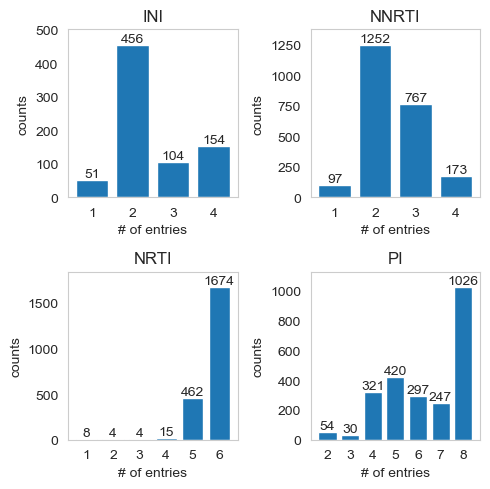

In [20]:
#checking the overlap of labels:

fig, axs = plt.subplots(2, 2, figsize=(5, 5), layout="tight")

axs = axs.flatten()

for i, file in enumerate(files):

    _, Y, drugs = data_preprocessing.hq_hiv_loader(file, drop_na=False)

    labels = Y.loc[:,drugs]

    label_overlap = labels.count(axis=1).value_counts().sort_index()

    print(file.split("/")[-1].strip("_DataSet.txt"))
    print(label_overlap)

    ax = axs[i]

    #ax.grid(False)
    rects = ax.bar(label_overlap.index.values.tolist(), label_overlap)
    #label_overlap.plot(kind="bar", ax=ax)
    ax.bar_label(rects)
    #ax.tick_params("x", rotation=0)
    print(list(range(label_overlap.shape[0])))
    ax.set_xticks(label_overlap.index.values.tolist())
    ax.set_title(file.split("/")[-1].strip("_DataSet.txt"))
    ax.set_xlabel("# of entries")
    ax.set_ylim(0, max(label_overlap) * 1.1)
    ax.set_ylabel("counts")
    ax.grid(False)

plt.savefig("./figures/01_target_properties/label_overlap_new4.png")


INI
0.5889426603202843
NNRTI
0.6821219606552231
NRTI
0.6034520101887427
PI
0.7016933170969312


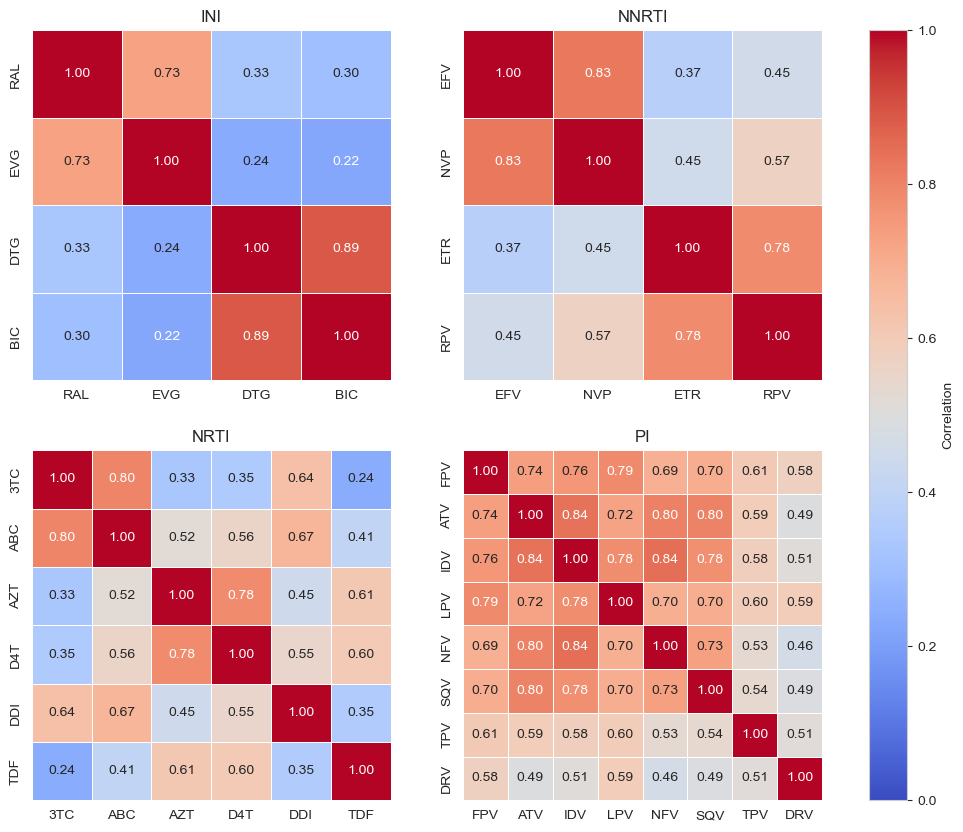

In [7]:

fig, axs = plt.subplots(2, 2, figsize=(12, 10))

axs = axs.flatten()

last_heatmap = None

for i, file in enumerate(files):
    X, Y, drugs = data_preprocessing.hq_hiv_loader(file, drop_na=False)

    ax = axs[i]
    print(file.split("/")[-1].strip("_DataSet.txt"))
    print(Y.corr().mean().mean())

    last_heatmap = sns.heatmap(Y.corr(),vmin=0, vmax = 1, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, ax=ax, cbar=False)
    ax.title.set_text(file.split("/")[-1].strip("_DataSet.txt"))

cbar = fig.colorbar(last_heatmap.collections[0], ax=axs, location="right", orientation='vertical', fraction=.1)
cbar.set_label("Correlation")

plt.savefig("./figures/01_target_properties/corr_heatmaps_w_data.png")


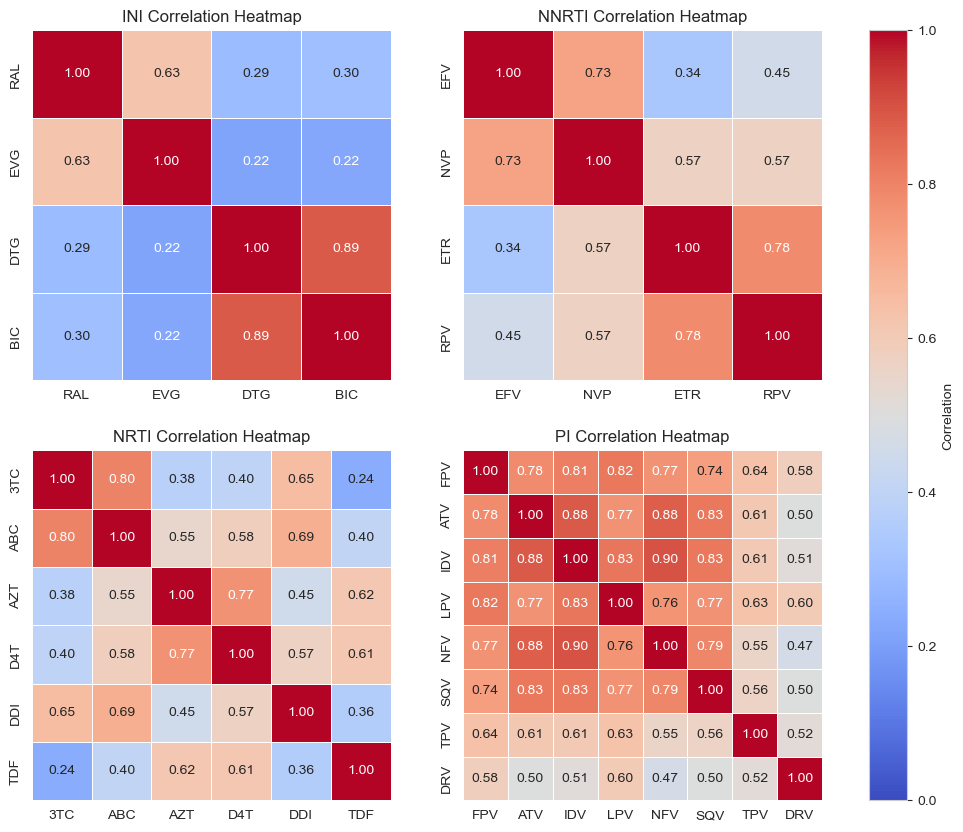

In [4]:

fig, axs = plt.subplots(2, 2, figsize=(12, 10))

axs = axs.flatten()

last_heatmap = None

for i, file in enumerate(files):
    X, Y, drugs = data_preprocessing.hq_hiv_loader(file, drop_na=True)

    ax = axs[i]

    last_heatmap = sns.heatmap(Y.corr(),vmin=0, vmax = 1, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, ax=ax, cbar=False)
    ax.title.set_text(file.split("/")[-1].strip("_DataSet.txt") + " Correlation Heatmap")

cbar = fig.colorbar(last_heatmap.collections[0], ax=axs, location="right", orientation='vertical', fraction=.1)
cbar.set_label("Correlation")

#plt.savefig("./figures/target_properties/corr_heatmaps.png")
